# 🏛️ BudgetFlow — Government Budget Dataset Generator
## Realistic Indian Government Budget Data (10,000 records)
### 8,000 Training | 2,000 Testing
---
**Rules:**
- All amounts in Indian Crores (₹ Cr) scale
- Realistic department-wise spending patterns
- Manually crafted anomaly patterns (not random)
- Labels: 0 = Normal | 1 = Warning | 2 = Anomaly

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2024)

print("✅ Libraries loaded")

✅ Libraries loaded


## Step 1: Define Realistic Base Data
All amounts are in ₹ Crores. Each department has its own realistic budget range and typical spending behavior.

In [2]:
# Each department has:
# - typical budget range (min, max) in Crores
# - typical spending efficiency (how well they usually spend)
# - fraud risk level (higher = more anomalies possible)

DEPARTMENT_PROFILES = {
    'Health': {
        'budget_range':  (50, 500),      # ₹50Cr to ₹500Cr
        'normal_spend':  (0.82, 0.96),   # typically spends 82-96% of budget
        'risk':          'medium'
    },
    'Education': {
        'budget_range':  (40, 400),
        'normal_spend':  (0.85, 0.98),   # schools spend almost everything
        'risk':          'low'
    },
    'Infrastructure': {
        'budget_range':  (100, 2000),    # roads/bridges = biggest budgets
        'normal_spend':  (0.70, 0.92),   # often delayed = underspend
        'risk':          'high'          # most fraud happens here
    },
    'Housing': {
        'budget_range':  (80, 800),
        'normal_spend':  (0.75, 0.95),
        'risk':          'high'
    },
    'Sanitation': {
        'budget_range':  (20, 200),
        'normal_spend':  (0.80, 0.97),
        'risk':          'medium'
    },
    'Agriculture': {
        'budget_range':  (30, 300),
        'normal_spend':  (0.60, 0.90),   # seasonal = often underspend
        'risk':          'medium'
    },
}

# District tiers — affects budget size they receive
DISTRICT_TIERS = {
    # Tier 1: Major cities — large budgets
    'Mumbai':      {'tier': 1, 'state': 'Maharashtra', 'population': 'high'},
    'Pune':        {'tier': 1, 'state': 'Maharashtra', 'population': 'high'},
    'Ahmedabad':   {'tier': 1, 'state': 'Gujarat',     'population': 'high'},
    'Surat':       {'tier': 1, 'state': 'Gujarat',     'population': 'high'},

    # Tier 2: Medium cities — medium budgets
    'Nashik':      {'tier': 2, 'state': 'Maharashtra', 'population': 'medium'},
    'Nagpur':      {'tier': 2, 'state': 'Maharashtra', 'population': 'medium'},
    'Vadodara':    {'tier': 2, 'state': 'Gujarat',     'population': 'medium'},
    'Rajkot':      {'tier': 2, 'state': 'Gujarat',     'population': 'medium'},

    # Tier 3: Rural — smaller budgets, more anomalies
    'Palghar':     {'tier': 3, 'state': 'Maharashtra', 'population': 'low'},
    'Raigad':      {'tier': 3, 'state': 'Maharashtra', 'population': 'low'},
    'Nandurbar':   {'tier': 3, 'state': 'Maharashtra', 'population': 'low'},
    'Dahanu':      {'tier': 3, 'state': 'Maharashtra', 'population': 'low'},
    'Bharuch':     {'tier': 3, 'state': 'Gujarat',     'population': 'low'},
    'Anand':       {'tier': 3, 'state': 'Gujarat',     'population': 'low'},
}

SCHEMES = [
    'Ayushman Bharat',
    'PM Awas Yojana',
    'PM Gram Sadak Yojana',
    'Sarva Shiksha Abhiyan',
    'Swachh Bharat Mission',
    'MGNREGA',
    'Jal Jeevan Mission',
    'PM Fasal Bima Yojana',
]

# 100 realistic contractors with fraud risk levels
CONTRACTORS = {f'C{str(i).zfill(3)}': {
    'name': f'Contractor_{i}',
    'fraud_risk': np.random.choice(['low','medium','high'],
                                    p=[0.60, 0.30, 0.10])
} for i in range(1, 101)}

print("✅ Department profiles defined")
print(f"   {len(DEPARTMENT_PROFILES)} departments")
print(f"   {len(DISTRICT_TIERS)} districts across Maharashtra & Gujarat")
print(f"   {len(SCHEMES)} central schemes")
print(f"   {len(CONTRACTORS)} contractors")

# Show department budget ranges
print("\n📊 Department Budget Ranges (₹ Cr):")
for dept, prof in DEPARTMENT_PROFILES.items():
    lo, hi = prof['budget_range']
    print(f"   {dept:15s}: ₹{lo}Cr – ₹{hi}Cr  | Risk: {prof['risk']}")

✅ Department profiles defined
   6 departments
   14 districts across Maharashtra & Gujarat
   8 central schemes
   100 contractors

📊 Department Budget Ranges (₹ Cr):
   Health         : ₹50Cr – ₹500Cr  | Risk: medium
   Education      : ₹40Cr – ₹400Cr  | Risk: low
   Infrastructure : ₹100Cr – ₹2000Cr  | Risk: high
   Housing        : ₹80Cr – ₹800Cr  | Risk: high
   Sanitation     : ₹20Cr – ₹200Cr  | Risk: medium
   Agriculture    : ₹30Cr – ₹300Cr  | Risk: medium


## Step 2: Build Realistic Records
Each record follows real-world government spending logic — not random noise.

In [3]:
def make_record(record_id, year, month, dept_name, district_name,
                label_type, contractor_id):
    """
    label_type: 'normal' | 'warning' | 'anomaly_over' | 'anomaly_under'
    """
    dept    = DEPARTMENT_PROFILES[dept_name]
    dist    = DISTRICT_TIERS[district_name]
    contr   = CONTRACTORS[contractor_id]

    # ── Allocated amount based on tier + department ──────────────────
    lo, hi = dept['budget_range']

    # Tier multiplier: tier 1 gets bigger budgets
    tier_mult = {1: 1.5, 2: 1.0, 3: 0.6}[dist['tier']]

    # Infrastructure projects always big
    if dept_name == 'Infrastructure':
        tier_mult *= 1.4

    allocated = round(
        np.random.uniform(lo * tier_mult, hi * tier_mult), 2
    )  # in Crores

    # ── Spent amount based on label type ─────────────────────────────
    lo_sp, hi_sp = dept['normal_spend']

    if label_type == 'normal':
        # 0–5% deviation → perfectly fine
        factor = np.random.uniform(lo_sp, hi_sp)

    elif label_type == 'warning':
        # 5–15% deviation — either over or under
        if np.random.rand() > 0.5:
            factor = np.random.uniform(1.05, 1.15)   # slight overspend
        else:
            factor = np.random.uniform(
                max(lo_sp - 0.15, 0.55), lo_sp - 0.05
            )                                         # slight underspend

    elif label_type == 'anomaly_over':
        # >15% OVERSPEND — contractor fraud / cost inflation
        factor = np.random.uniform(1.16, 1.60)

    elif label_type == 'anomaly_under':
        # >15% UNDERSPEND — fund stalling / not reaching ground
        factor = np.random.uniform(0.10, 0.50)

    spent = round(allocated * factor, 2)

    # ── Derived features ─────────────────────────────────────────────
    diff          = abs(allocated - spent)
    diff_pct      = round((diff / allocated) * 100, 2)
    spending_ratio= round(spent / allocated, 4)
    is_overspend  = 1 if spent > allocated else 0

    # Completion % — correlated with spending
    if label_type == 'normal':
        completion = int(np.random.uniform(60, 95))
    elif label_type == 'warning':
        completion = int(np.random.uniform(35, 70))
    elif label_type == 'anomaly_over':
        completion = int(np.random.uniform(20, 55))  # paid a lot but low completion = fraud
    elif label_type == 'anomaly_under':
        completion = int(np.random.uniform(5,  30))  # stalled project

    # Numeric label
    label_map = {
        'normal':        0,
        'warning':       1,
        'anomaly_over':  2,
        'anomaly_under': 2
    }
    label = label_map[label_type]

    return {
        'record_id':       f'REC{str(record_id).zfill(5)}',
        'year':            year,
        'month':           month,
        'quarter':         (month - 1) // 3 + 1,
        'department':      dept_name,
        'district':        district_name,
        'state':           dist['state'],
        'scheme':          np.random.choice(SCHEMES),
        'contractor_id':   contractor_id,
        'contractor_risk': contr['fraud_risk'],
        'district_tier':   dist['tier'],

        # Amounts (₹ Crores)
        'centre_released':     round(allocated * 1.05, 2),
        'state_allocated':     round(allocated * 1.02, 2),
        'district_allocated':  allocated,
        'contractor_paid':     spent,

        # Features
        'diff_amount':         round(diff, 2),
        'diff_percent':        diff_pct,
        'spending_ratio':      spending_ratio,
        'is_overspend':        is_overspend,
        'completion_pct':      completion,

        # Label
        'label_type':  label_type,
        'label':       label,
        'risk_level':  ['green', 'yellow', 'red'][label]
    }

print("✅ Record generator function ready")
print("\nLabel mapping:")
print("   0 = Normal  (green)  → 0-5% deviation")
print("   1 = Warning (yellow) → 5-15% deviation")
print("   2 = Anomaly (red)    → >15% deviation (over OR under)")

✅ Record generator function ready

Label mapping:
   0 = Normal  (green)  → 0-5% deviation
   1 = Warning (yellow) → 5-15% deviation
   2 = Anomaly (red)    → >15% deviation (over OR under)


## Step 3: Generate 10,000 Records with Controlled Distribution
- 7,000 Normal records
- 1,500 Warning records
- 1,500 Anomaly records (750 overspend + 750 underspend)

In [4]:
records = []
record_id = 1

years   = [2021, 2022, 2023, 2024]
months  = list(range(1, 13))
depts   = list(DEPARTMENT_PROFILES.keys())
dists   = list(DISTRICT_TIERS.keys())
conts   = list(CONTRACTORS.keys())

def batch(n, label_type):
    global record_id
    batch_records = []
    for _ in range(n):
        batch_records.append(make_record(
            record_id   = record_id,
            year        = np.random.choice(years),
            month       = np.random.choice(months),
            dept_name   = np.random.choice(depts),
            district_name = np.random.choice(dists),
            label_type  = label_type,
            contractor_id = np.random.choice(conts)
        ))
        record_id += 1
    return batch_records

print("🔄 Generating records...")

# ── 7,000 NORMAL records ──────────────────────────────────────────────
records += batch(7000, 'normal')
print(f"   ✅ 7,000 Normal records generated")

# ── 1,500 WARNING records ─────────────────────────────────────────────
records += batch(1500, 'warning')
print(f"   ✅ 1,500 Warning records generated")

# ── 750 ANOMALY OVERSPEND records ────────────────────────────────────
records += batch(750, 'anomaly_over')
print(f"   ✅ 750 Anomaly (Overspend) records generated")

# ── 750 ANOMALY UNDERSPEND records ───────────────────────────────────
records += batch(750, 'anomaly_under')
print(f"   ✅ 750 Anomaly (Underspend) records generated")

# Build DataFrame and shuffle
df = pd.DataFrame(records)
df = df.sample(frac=1, random_state=2024).reset_index(drop=True)

print(f"\n✅ Full dataset: {len(df):,} records")
print(f"\n📊 Label Distribution:")
print(f"   Normal  (0): {(df.label==0).sum():,}  ({(df.label==0).mean()*100:.1f}%)")
print(f"   Warning (1): {(df.label==1).sum():,}  ({(df.label==1).mean()*100:.1f}%)")
print(f"   Anomaly (2): {(df.label==2).sum():,}  ({(df.label==2).mean()*100:.1f}%)")
print(f"\n💰 Amount Statistics (₹ Crores):")
print(df[['district_allocated', 'contractor_paid', 'diff_percent']].describe().round(2).to_string())

🔄 Generating records...
   ✅ 7,000 Normal records generated
   ✅ 1,500 Warning records generated
   ✅ 750 Anomaly (Overspend) records generated
   ✅ 750 Anomaly (Underspend) records generated

✅ Full dataset: 10,000 records

📊 Label Distribution:
   Normal  (0): 7,000  (70.0%)
   Warning (1): 1,500  (15.0%)
   Anomaly (2): 1,500  (15.0%)

💰 Amount Statistics (₹ Crores):
       district_allocated  contractor_paid  diff_percent
count            10000.00         10000.00      10000.00
mean               443.30           369.45         21.96
std                637.68           547.30         17.96
min                 12.17             2.65          2.05
25%                110.35            87.10         10.12
50%                217.39           180.54         15.68
75%                445.59           380.48         27.52
max               4197.59          6426.54         89.99


## Step 4: Verify the Data Looks Realistic

In [5]:
print("=" * 55)
print("DATA QUALITY REPORT")
print("=" * 55)

# Check 1: Amount ranges make sense
print("\n✅ CHECK 1 — Budget Ranges (₹ Cr) by Department:")
dept_check = df.groupby('department')['district_allocated'].agg(['min','mean','max']).round(1)
print(dept_check.to_string())

# Check 2: Spending ratios per label
print("\n✅ CHECK 2 — Spending Ratio by Label:")
ratio_check = df.groupby('label_type')['spending_ratio'].agg(['min','mean','max']).round(3)
print(ratio_check.to_string())

# Check 3: Diff percent ranges
print("\n✅ CHECK 3 — Deviation % Ranges by Label:")
diff_check = df.groupby('label_type')['diff_percent'].agg(['min','mean','max']).round(2)
print(diff_check.to_string())

# Check 4: No impossible values
has_negative_alloc = (df['district_allocated'] <= 0).sum()
has_negative_spent = (df['contractor_paid'] < 0).sum()
has_null           = df.isnull().sum().sum()
print(f"\n✅ CHECK 4 — Data Integrity:")
print(f"   Negative allocations : {has_negative_alloc}")
print(f"   Negative spent       : {has_negative_spent}")
print(f"   Null values          : {has_null}")

# Check 5: Sample rows
print(f"\n✅ CHECK 5 — 3 Sample Records per Label:")
for ltype in ['normal', 'warning', 'anomaly_over', 'anomaly_under']:
    row = df[df['label_type'] == ltype].iloc[0]
    print(f"\n  [{ltype.upper()}]")
    print(f"   Dept: {row['department']:15s} | District: {row['district']}")
    print(f"   Allocated: ₹{row['district_allocated']:.2f}Cr | Paid: ₹{row['contractor_paid']:.2f}Cr")
    print(f"   Deviation: {row['diff_percent']:.1f}% | Risk: {row['risk_level'].upper()}")

DATA QUALITY REPORT

✅ CHECK 1 — Budget Ranges (₹ Cr) by Department:
                 min    mean     max
department                          
Agriculture     18.0   159.7   449.8
Education       24.0   215.8   597.8
Health          30.2   268.7   749.3
Housing         49.0   416.3  1198.5
Infrastructure  84.6  1447.5  4197.6
Sanitation      12.2   106.8   299.7

✅ CHECK 2 — Spending Ratio by Label:
                 min   mean    max
label_type                        
anomaly_over   1.160  1.374  1.599
anomaly_under  0.100  0.295  0.498
normal         0.601  0.849  0.980
warning        0.550  0.884  1.150

✅ CHECK 3 — Deviation % Ranges by Label:
                 min   mean    max
label_type                        
anomaly_over   16.02  37.41  59.93
anomaly_under  50.23  70.53  89.99
normal          2.05  15.14  39.89
warning         5.00  21.79  45.01

✅ CHECK 4 — Data Integrity:
   Negative allocations : 0
   Negative spent       : 0
   Null values          : 0

✅ CHECK 5 — 3 Sample 

## Step 5: Visualize the Dataset

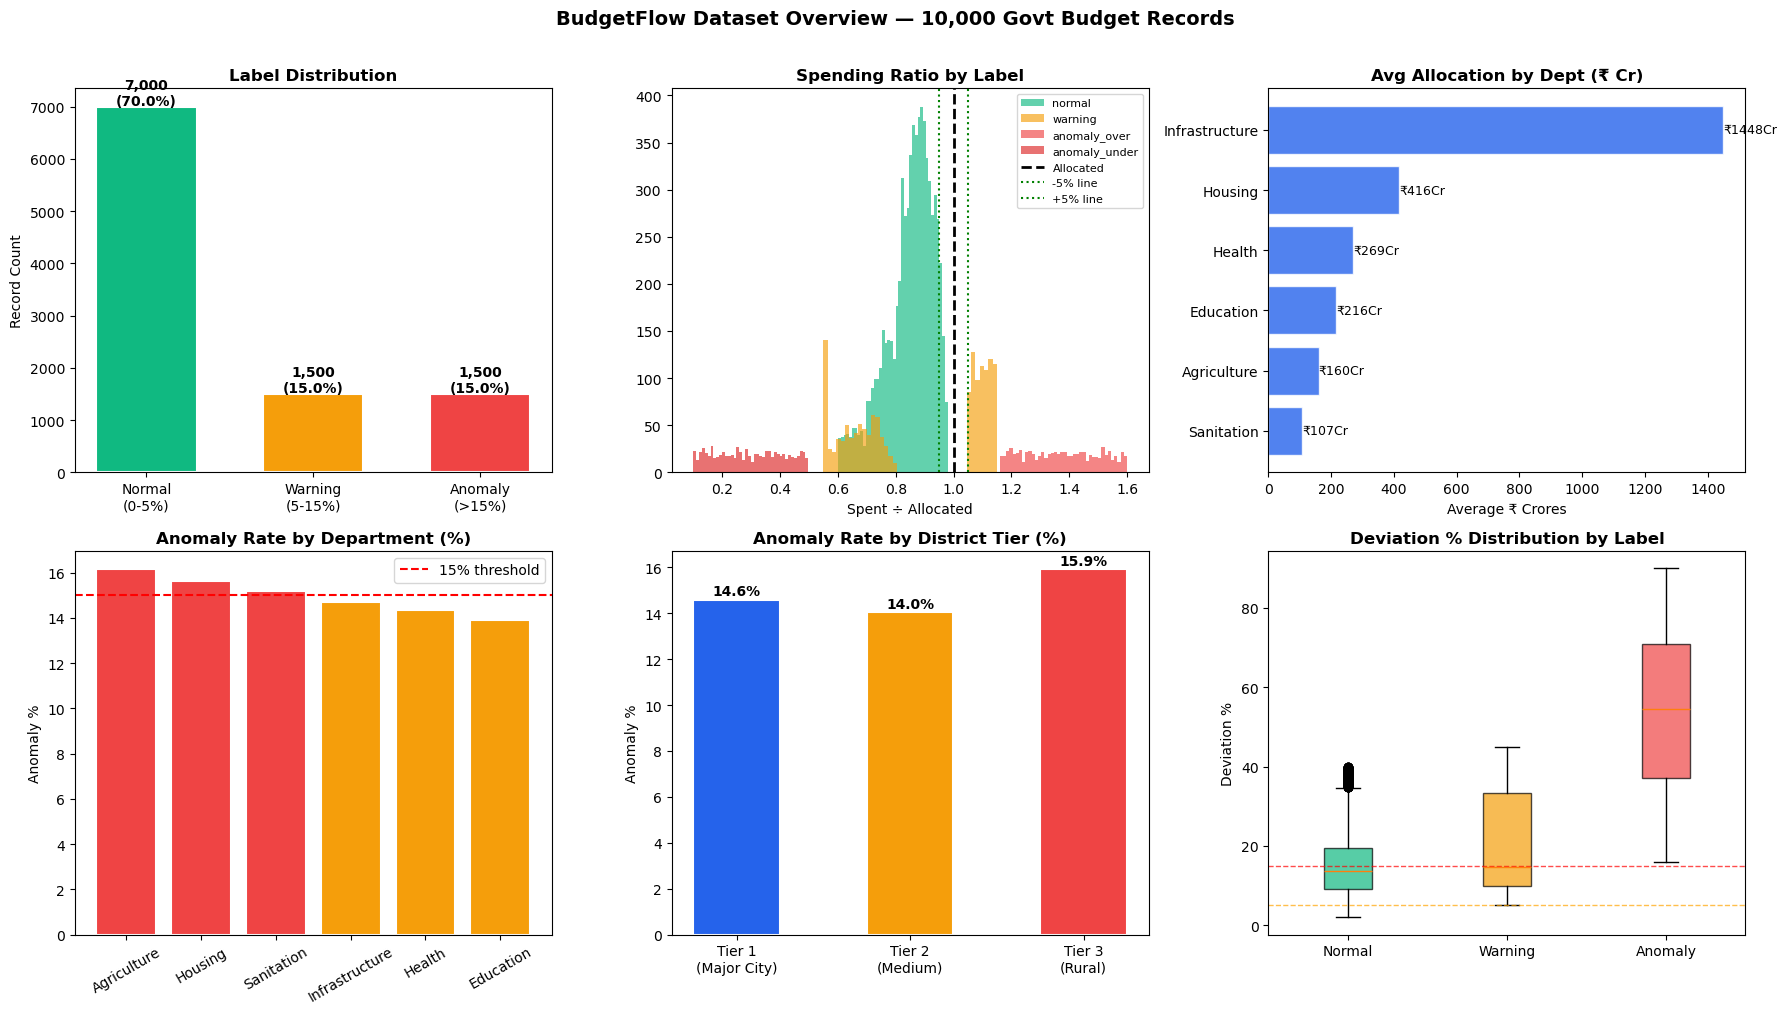

✅ Visualization saved as dataset_overview.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('BudgetFlow Dataset Overview — 10,000 Govt Budget Records',
             fontsize=14, fontweight='bold', y=1.01)

colors = {'normal':'#10b981', 'warning':'#f59e0b',
          'anomaly_over':'#ef4444', 'anomaly_under':'#dc2626'}
label_colors = ['#10b981', '#f59e0b', '#ef4444']

# Plot 1: Label distribution
labels_count = df['label'].value_counts().sort_index()
axes[0,0].bar(['Normal\n(0-5%)', 'Warning\n(5-15%)', 'Anomaly\n(>15%)'],
               labels_count.values,
               color=label_colors, edgecolor='white', linewidth=1.5, width=0.6)
axes[0,0].set_title('Label Distribution', fontweight='bold')
axes[0,0].set_ylabel('Record Count')
for i, v in enumerate(labels_count.values):
    axes[0,0].text(i, v + 30, f'{v:,}\n({v/100:.1f}%)', ha='center',
                   fontsize=10, fontweight='bold')

# Plot 2: Spending ratio distribution by label
for ltype, color in colors.items():
    subset = df[df['label_type'] == ltype]['spending_ratio']
    axes[0,1].hist(subset, bins=40, alpha=0.65, label=ltype, color=color)
axes[0,1].axvline(x=1.0, color='black', linestyle='--', linewidth=2, label='Allocated')
axes[0,1].axvline(x=0.95, color='green', linestyle=':', linewidth=1.5, label='-5% line')
axes[0,1].axvline(x=1.05, color='green', linestyle=':', linewidth=1.5, label='+5% line')
axes[0,1].set_title('Spending Ratio by Label', fontweight='bold')
axes[0,1].set_xlabel('Spent ÷ Allocated')
axes[0,1].legend(fontsize=8)

# Plot 3: Department-wise average allocation
dept_avg = df.groupby('department')['district_allocated'].mean().sort_values()
axes[0,2].barh(dept_avg.index, dept_avg.values,
               color='#2563eb', alpha=0.8, edgecolor='white')
axes[0,2].set_title('Avg Allocation by Dept (₹ Cr)', fontweight='bold')
axes[0,2].set_xlabel('Average ₹ Crores')
for i, v in enumerate(dept_avg.values):
    axes[0,2].text(v + 1, i, f'₹{v:.0f}Cr', va='center', fontsize=9)

# Plot 4: Anomaly rate by department
dept_anomaly = df.groupby('department').apply(
    lambda x: (x['label'] == 2).mean() * 100
).sort_values(ascending=False)
bar_colors_dept = ['#ef4444' if v > 15 else '#f59e0b' if v > 10 else '#10b981'
                   for v in dept_anomaly.values]
axes[1,0].bar(dept_anomaly.index, dept_anomaly.values,
              color=bar_colors_dept, edgecolor='white', linewidth=1.5)
axes[1,0].axhline(y=15, color='red', linestyle='--', linewidth=1.5, label='15% threshold')
axes[1,0].set_title('Anomaly Rate by Department (%)', fontweight='bold')
axes[1,0].set_ylabel('Anomaly %')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].legend()

# Plot 5: District tier vs anomaly rate
tier_anomaly = df.groupby('district_tier').apply(
    lambda x: (x['label'] == 2).mean() * 100
)
tier_labels = ['Tier 1\n(Major City)', 'Tier 2\n(Medium)', 'Tier 3\n(Rural)']
axes[1,1].bar(tier_labels, tier_anomaly.values,
              color=['#2563eb','#f59e0b','#ef4444'],
              edgecolor='white', linewidth=1.5, width=0.5)
axes[1,1].set_title('Anomaly Rate by District Tier (%)', fontweight='bold')
axes[1,1].set_ylabel('Anomaly %')
for i, v in enumerate(tier_anomaly.values):
    axes[1,1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 6: Deviation % boxplot by label
data_box = [df[df['label']==i]['diff_percent'].values for i in range(3)]
bp = axes[1,2].boxplot(data_box, labels=['Normal', 'Warning', 'Anomaly'],
                        patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], label_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1,2].set_title('Deviation % Distribution by Label', fontweight='bold')
axes[1,2].set_ylabel('Deviation %')
axes[1,2].axhline(y=5,  color='orange', linestyle='--', linewidth=1, alpha=0.7)
axes[1,2].axhline(y=15, color='red',    linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization saved as dataset_overview.png")

## Step 6: Train / Test Split (8,000 / 2,000)
Stratified split so both sets have same proportion of Normal/Warning/Anomaly

In [7]:
from sklearn.model_selection import train_test_split

# Features used for ML model
ML_FEATURES = [
    'district_allocated',
    'contractor_paid',
    'diff_amount',
    'diff_percent',
    'spending_ratio',
    'is_overspend',
    'completion_pct',
    'district_tier',
    'month',
    'quarter',
]

X = df[ML_FEATURES]
y = df['label']

# Stratified split keeps same label ratio in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,    # 20% = 2,000 test
    random_state = 2024,
    stratify     = y        # IMPORTANT: keeps ratio same
)

train_df = df.iloc[X_train.index].copy()
test_df  = df.iloc[X_test.index].copy()

print("=" * 50)
print("TRAIN / TEST SPLIT SUMMARY")
print("=" * 50)

print(f"\n📦 TRAINING SET: {len(train_df):,} records")
print(f"   Normal  (0): {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.1f}%)")
print(f"   Warning (1): {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.1f}%)")
print(f"   Anomaly (2): {(y_train==2).sum():,}  ({(y_train==2).mean()*100:.1f}%)")

print(f"\n🧪 TESTING SET:  {len(test_df):,} records")
print(f"   Normal  (0): {(y_test==0).sum():,}  ({(y_test==0).mean()*100:.1f}%)")
print(f"   Warning (1): {(y_test==1).sum():,}  ({(y_test==1).mean()*100:.1f}%)")
print(f"   Anomaly (2): {(y_test==2).sum():,}  ({(y_test==2).mean()*100:.1f}%)")

print(f"\n✅ Ratio is consistent across both sets")

TRAIN / TEST SPLIT SUMMARY

📦 TRAINING SET: 8,000 records
   Normal  (0): 5,600  (70.0%)
   Warning (1): 1,200  (15.0%)
   Anomaly (2): 1,200  (15.0%)

🧪 TESTING SET:  2,000 records
   Normal  (0): 1,400  (70.0%)
   Warning (1): 300  (15.0%)
   Anomaly (2): 300  (15.0%)

✅ Ratio is consistent across both sets


## Step 7: Save All Files

In [8]:
import os
os.makedirs('dataset', exist_ok=True)

# Save full dataset
df.to_csv('dataset/budget_full_10000.csv', index=False)
print(f"✅ Full dataset saved    → dataset/budget_full_10000.csv  ({len(df):,} rows)")

# Save train set
train_df.to_csv('dataset/budget_train_8000.csv', index=False)
print(f"✅ Training set saved    → dataset/budget_train_8000.csv  ({len(train_df):,} rows)")

# Save test set
test_df.to_csv('dataset/budget_test_2000.csv', index=False)
print(f"✅ Testing set saved     → dataset/budget_test_2000.csv   ({len(test_df):,} rows)")

# Save X_train, X_test, y_train, y_test as numpy for direct model loading
import numpy as np
np.save('dataset/X_train.npy', X_train.values)
np.save('dataset/X_test.npy',  X_test.values)
np.save('dataset/y_train.npy', y_train.values)
np.save('dataset/y_test.npy',  y_test.values)
print(f"✅ Numpy arrays saved    → dataset/X_train.npy, X_test.npy, y_train.npy, y_test.npy")

print("\n" + "="*50)
print("🎉 DATASET GENERATION COMPLETE!")
print("="*50)
print("\n📁 dataset/ folder contents:")
for f in sorted(os.listdir('dataset')):
    size = os.path.getsize(f'dataset/{f}')
    print(f"   {f:35s}  {size/1024:.1f} KB")

print(f"""
📊 DATASET SUMMARY:
   Total records   : 10,000
   Training set    : 8,000  (80%)
   Testing set     : 2,000  (20%)
   Normal records  : 7,000  (70%)
   Warning records : 1,500  (15%)
   Anomaly records : 1,500  (15%)
   Features        : {len(ML_FEATURES)}
   Amount range    : ₹12Cr – ₹3,000Cr (realistic govt scale)
""")

✅ Full dataset saved    → dataset/budget_full_10000.csv  (10,000 rows)
✅ Training set saved    → dataset/budget_train_8000.csv  (8,000 rows)
✅ Testing set saved     → dataset/budget_test_2000.csv   (2,000 rows)
✅ Numpy arrays saved    → dataset/X_train.npy, X_test.npy, y_train.npy, y_test.npy

🎉 DATASET GENERATION COMPLETE!

📁 dataset/ folder contents:
   X_test.npy                           156.4 KB
   X_train.npy                          625.1 KB
   budget_full_10000.csv                1409.7 KB
   budget_test_2000.csv                 282.3 KB
   budget_train_8000.csv                1127.6 KB
   y_test.npy                           15.8 KB
   y_train.npy                          62.6 KB

📊 DATASET SUMMARY:
   Total records   : 10,000
   Training set    : 8,000  (80%)
   Testing set     : 2,000  (20%)
   Normal records  : 7,000  (70%)
   Warning records : 1,500  (15%)
   Anomaly records : 1,500  (15%)
   Features        : 10
   Amount range    : ₹12Cr – ₹3,000Cr (realistic govt scale)

## ✅ Next Step
Run `ml_models.ipynb` to train Model 1 (Anomaly Detection) and Model 2 (Reallocation) on this dataset.

Load data in next notebook with:
```python
import numpy as np, pandas as pd
X_train = np.load('dataset/X_train.npy')
X_test  = np.load('dataset/X_test.npy')
y_train = np.load('dataset/y_train.npy')
y_test  = np.load('dataset/y_test.npy')
train_df = pd.read_csv('dataset/budget_train_8000.csv')
```